# Markov Decision Processes

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse.linalg as linalg
import scipy.linalg as slin
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import sys
sys.path.insert(0, '../../load_data')
from load import load_stats, load_history

pd.options.mode.chained_assignment = None

from collections import deque

## Load Data

In [2]:
history = load_history()

In [44]:
majors = pd.read_csv("md_player_usatt_tournament_costs.csv", index_col='Tournament')

tournaments = majors.index.to_numpy()
ids = majors["ID"].to_numpy()
dates = [[1,2,3,4,5,6,7,8,9,10,11,12], [7], [12], [5], [1,2,3,4,5,6,7,8,9,10,11,12], [3, 6, 10, 12], [8], [11], [5], [5], [1,2,3,4,5,6,7,8,9,10,11,12]]
costs = majors['Total Cost']

## Data Preparation

In [4]:
# assigning a stochastic matrix for each tournament (these are the transition probabilities)

bin_width = 100
bins = np.arange(0, 3000, bin_width)
labels = np.arange(0, bins.size-1)
p_size = bins.size-1

# first entry are zeros for the "Home" tournament (staying at home)
P = [np.eye(p_size, p_size)]

for id in ids[1:]:
    tournament = pd.read_csv(f"./major_tournament_history_data/{id}.csv")

    transitions = tournament[['Initial Rating', 'Final Rating']]
    transitions['initial bin'] = pd.cut(transitions['Initial Rating'], bins, labels=labels, include_lowest=True)
    transitions['final bin'] = pd.cut(transitions['Final Rating'], bins, labels=labels, include_lowest=True)
    transitions = transitions[['initial bin', 'final bin']]

    probs = (transitions.value_counts() / transitions.value_counts().groupby(level=0, observed=True).sum())
    p = np.zeros((p_size, p_size))

    for i, f in probs.index:
        p[i, f] = probs[i, f]

    P.append(p)

P = np.array(P)

In [5]:
# the expected reward is the expected number of bins to shift up or down given the current bin
# the mean expected reward is the average of all expected rewards across all ratings

rewards = np.zeros((p_size, p_size))
for reward in P:
    for i in range(p_size):
        rewards[i] = np.arange(0, p_size) - i

expected_rewards = []

expected_rewards = (P * rewards).sum(axis=1)

expected_rewards = np.array(expected_rewards)
mean_expected_rewards = np.mean(expected_rewards, axis=1)

In [6]:
# define a tournament

class Tournament:
    def __init__(self, name, month, cost, P, reward, expected_reward, mean_expected_reward):
        self.name = name
        self.month = month
        self.cost = cost
        self.P = P
        self.reward = reward
        self.expected_reward = expected_reward
        self.mean_expected_reward = mean_expected_reward
    
    def __str__(self):
        return self.name

    def __repr__(self):
        return self.name
    
    def __hash__(self):
        return hash(self.name)
    
    def __eq__(self, value):
        return self.name == value.name

## Define an MDP

In [7]:
class MDP:
    def __init__(self, s, a, P, r, ra, b):
        self.states = s
        self.actions = a
        self.P = P
        self.rewards = r
        self.rating = ra
        self.budget = b


    # ---------- Solve by Enumeration ----------

    def find_paths(self):
        results = []
        path = []

        def generate_paths(index, count):
            if sum([tournament.cost for tournament in path]) > self.budget:
                if count == 0:
                    results.append(list(path[:-1]))
                return 1
            if index == len(self.actions):
                results.append(list(path))
                return 0

            dupes = 0
            current_list = self.actions[index]
            for action in current_list:
                path.append(action)
                dupes += generate_paths(index + 1, dupes)
                path.pop()

            return 0

        generate_paths(0, 0)
        return results

    def optimal_mean_path(self, paths=[]):
        if len(paths) == 0:
            paths = self.find_paths()

        path_mean_expected_reward = [sum([tournament.mean_expected_reward for tournament in path]) for path in paths]

        index = np.argmax(path_mean_expected_reward)
        cost = sum([tournament.cost for tournament in paths[index]])

        print("---------- mean ----------")
        print(f"index: {index}/{len(paths)}")
        print(f"cost: ${cost}")
        print(f"reward: {path_mean_expected_reward[index]}")
        print(f"path: {paths[index]}")
        print()

        return paths[index], path_mean_expected_reward[index]
    
    def optimal_path(self, paths=[]):
        bin = self.rating // 100

        if len(paths) == 0:
            paths = self.find_paths()

        expected_reward_paths = [sum([tournament.expected_reward[bin] for tournament in path]) for path in paths]

        index = np.argmax(expected_reward_paths)
        cost = sum([tournament.cost for tournament in paths[index]])

        print("---------- rating ----------")
        print(f"index: {index}/{len(paths)}")
        print(f"cost: ${cost}")
        print(f"reward: {expected_reward_paths[index]}")
        print(f"path: {paths[index]}")
        print()

        return paths[index], expected_reward_paths[index]
    
    def optimal_markov_path(self, paths=[]):
        bin = self.rating // 100

        if len(paths) == 0:
            paths = self.find_paths()

        expected_reward_paths = []
        for path in paths:
            reward = np.zeros(p_size)
            reward[bin] = 1
            for tournament in path:
                reward = reward @ tournament.P
            expected_reward_paths.append(np.dot(reward, np.arange(p_size) - bin))

        index = np.argmax(expected_reward_paths)
        cost = sum([tournament.cost for tournament in paths[index]])
        
        print("---------- markov process ----------")
        print(f"index: {index}/{len(paths)}")
        print(f"cost: ${cost}")
        print(f"reward: {expected_reward_paths[index]}")
        print(f"optimal path: {paths[index]}")
        print()

        return paths[index], expected_reward_paths[index]
    
    
    def all_optimal_paths(self):
        print(f"rating: {self.rating}")
        print(f"budget: ${self.budget}")
        print()

        print("-------------------- ENUMERATION --------------------")
        paths = self.find_paths()

        self.optimal_mean_path(paths)
        self.optimal_path(paths)
        self.optimal_markov_path(paths)

## Test MDP

In [41]:
months = 9

states = np.arange(0,months)

actions = [[] for i in range(months)]
for i, date in enumerate(dates):
    for month in date:
        for j in range(month, months+1, 12):
            actions[j-1].append(Tournament(tournaments[i], dates[i], costs.iloc[i], P[i], rewards, expected_rewards[i], mean_expected_rewards[i]))

transitions = np.eye(months, months, 1)

rating = 1500

budget = 20000

mdp = MDP(states, actions, transitions, P, rating, budget)

In [42]:
mdp.all_optimal_paths()
print()

rating: 1500
budget: $20000

-------------------- ENUMERATION --------------------
---------- mean ----------
index: 124391/124416
cost: $10214
reward: 7.085865911023641
path: [BTTC, BTTC, BTTC, BTTC, BTTC, BTTC, Nationals, BTTC, BTTC]

---------- rating ----------
index: 124415/124416
cost: $9108
reward: 13.485755364499648
path: [BTTC, BTTC, BTTC, BTTC, BTTC, BTTC, BTTC, BTTC, BTTC]

---------- markov process ----------
index: 123623/124416
cost: $10342
reward: 1.5701426309886133
optimal path: [BTTC, BTTC, BTTC, BTTC, Team Trials, BTTC, Nationals, BTTC, BTTC]




## Define CMDP

In [9]:
class Node:
    def __init__(self, budget, epoch=0) -> None:
        self.budget = budget
        self.actions = []
        self.q = np.zeros(p_size)
        self.epoch = epoch
        self.children = []
    
    def __repr__(self):
        return f"${self.budget}, epoch {self.epoch}"
    
    def __str__(self, level=0):
        return f"${self.budget}, epoch {self.epoch}"
    
    def __eq__(self, value) -> bool:
        return self.budget == value.budget and self.epoch == value.epoch
    
    def __hash__(self) -> int:
        return hash((self.budget, self.epoch))

class CMDP:
    def __init__(self, starting_budget, a, P, r, ra, gamma=0.9) -> None:
        self.actions = a
        self.P = P
        self.rewards = r
        self.rating = ra
        self.gamma = gamma

        self.root = Node(starting_budget)
        
        queue = deque()
        queue.append(self.root)
        existing_nodes = {(self.root.budget, self.root.epoch): self.root}

        while queue:
            current = queue.popleft()

            if current.epoch == len(self.actions):
                continue
            
            for tournament in self.actions[current.epoch]:
                if current.budget - tournament.cost >= 0:
                    current.actions.append(tournament)

                    new_budget = current.budget - tournament.cost
                    new_epoch = current.epoch + 1

                    if (new_budget, new_epoch) not in existing_nodes:
                        current.children.append(Node(new_budget, epoch=new_epoch))
                        existing_nodes[(new_budget, new_epoch)] = current.children[-1]
                        queue.append(current.children[-1])
                    else:
                        current.children.append(existing_nodes[(new_budget, new_epoch)])

        print(f"node count: {len(existing_nodes)}")



    # satisfies bellman's equations
    def q_value(self, node, index):
        action = node.actions[index]
        values = np.zeros(p_size)

        if node.epoch == len(self.actions):
            return action.expected_reward
        
        for i in range(p_size):
            values[i] = np.sum(action.P[i] * (action.reward[i] + self.gamma * node.children[index].q))
        
        return values
        


        
    def policy_extraction(self):
        optimal_policy = []
        total_q_value = 0

        current = self.root

        while current.children:
            q_values = np.array([self.q_value(current, i) for i in range(len(current.actions))])

            max_index = np.argmax(q_values, axis=0)
            optimal_policy.append(np.array(current.actions)[max_index])
            total_q_value += np.max(q_values)

            current = current.children[max_index[self.rating // 100]]

        # fill in empty policy slots with "stay at home"
        while len(optimal_policy) < len(self.actions):
            optimal_policy.append([self.actions[0][0] for i in range(p_size)])
        
        return np.array(optimal_policy), total_q_value




    def optimal_val_iter_path(self, delta_lim=0.01, plot=False):
        print("---------- value iteration ----------")

        # do while loop
        iterations = 0
        # q_val_history = []
        # max_delta_history = []
        
        while True:
            queue = deque()
            queue.append(self.root)
            max_delta = 0

            visited = set()

            while queue:
                current = queue.popleft()

                if current in visited:
                    continue

                q_values = [self.q_value(current, i) for i in range(len(current.actions))]
                if len(current.actions) > 1:
                    max_q = q_values[0]
                    for q_arr in q_values[1:]:
                        max_q = np.maximum(max_q, q_arr)
                else:
                    max_q = current.q
                
                max_delta = max(max_delta, np.max(np.abs(current.q - max_q)))
                current.q = max_q

                visited.add(current)

                queue.extend(current.children)
            
            iterations += 1

            # if plot:
            #     val_iter_path, q_val = self.policy_extraction()
            #     q_val_history.append(q_val)
            #     max_delta_history.append(max_delta)

            print(f"iteration {iterations}, max delta: {max_delta}")
            if max_delta <= delta_lim:
                break
            

        optimal_path, q_val = self.policy_extraction()
        # cost = sum([tournament.cost for tournament in optimal_path])
        # expected_reward = sum([tournament.expected_reward[self.rating // 100] for tournament in optimal_path])

        print("---------- results ----------")
        print(f"iterations: {iterations}")
        # print(f"cost: ${cost} / ${self.root.budget}")
        print(f"q_value: {q_val}")
        # print(f"expected reward: {expected_reward}")
        print(f"optimal path: {optimal_path}")

        # if plot:
        #     plt.figure(figsize=(15, 6))

        #     plt.subplot(121)
        #     sns.scatterplot(x=np.arange(iterations), y=q_val_history)
        #     plt.title("q-value over time")
        #     plt.xlabel('iteration')
        #     plt.ylabel('optimal path q-value')

        #     plt.subplot(122)
        #     sns.scatterplot(x=np.arange(iterations), y=max_delta_history)
        #     plt.title("max delta over time")
        #     plt.xlabel('iteration')
        #     plt.ylabel('max delta')
        #     plt.show()

        return optimal_path, q_val

## Test CMDP

In [79]:
months = 12

actions = [[] for i in range(months)]
for i, date in enumerate(dates):
    for month in date:
        for j in range(month, months+1, 12):
            actions[j-1].append(Tournament(tournaments[i], dates[i], costs.iloc[i], P[i], rewards, expected_rewards[i], mean_expected_rewards[i]))

rating = 2500

budget = 10000

cmdp = CMDP(budget, actions, P, rewards, rating)

optimal_path, q_val = cmdp.optimal_val_iter_path(plot=True)
print()

node count: 10878
---------- value iteration ----------
iteration 1, max delta: 14.896969696969695
iteration 2, max delta: 3.1501781425405717
iteration 3, max delta: 2.39034001684892
iteration 4, max delta: 1.7563755286227356
iteration 5, max delta: 1.1902114896055327
iteration 6, max delta: 0.9365553004117908
iteration 7, max delta: 0.7507087163416131
iteration 8, max delta: 0.6412598002612153
iteration 9, max delta: 0.5229430326033571
iteration 10, max delta: 0.4146556924429792
iteration 11, max delta: 0.340457462184351
iteration 12, max delta: 0.08812730984971484
iteration 13, max delta: 0
---------- results ----------
iterations: 13
q_value: 174.34417423020005
optimal path: [[BTTC Westchester Westchester Westchester BTTC BTTC BTTC BTTC BTTC BTTC
  Westchester Westchester BTTC Westchester Westchester BTTC BTTC
  Westchester BTTC BTTC Westchester Westchester Westchester BTTC Home
  BTTC Westchester Home Home]
 [BTTC Westchester Westchester Westchester BTTC BTTC BTTC BTTC BTTC BTTC
  

C:\Users\hsu_s\AppData\Local\Temp\ipykernel_30596\3806821325.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sns.heatmap(pd.DataFrame(optimal_path.T).replace(value_to_int), cmap=cmap, annot=optimal_path.T.astype(str), fmt='', cbar=False)


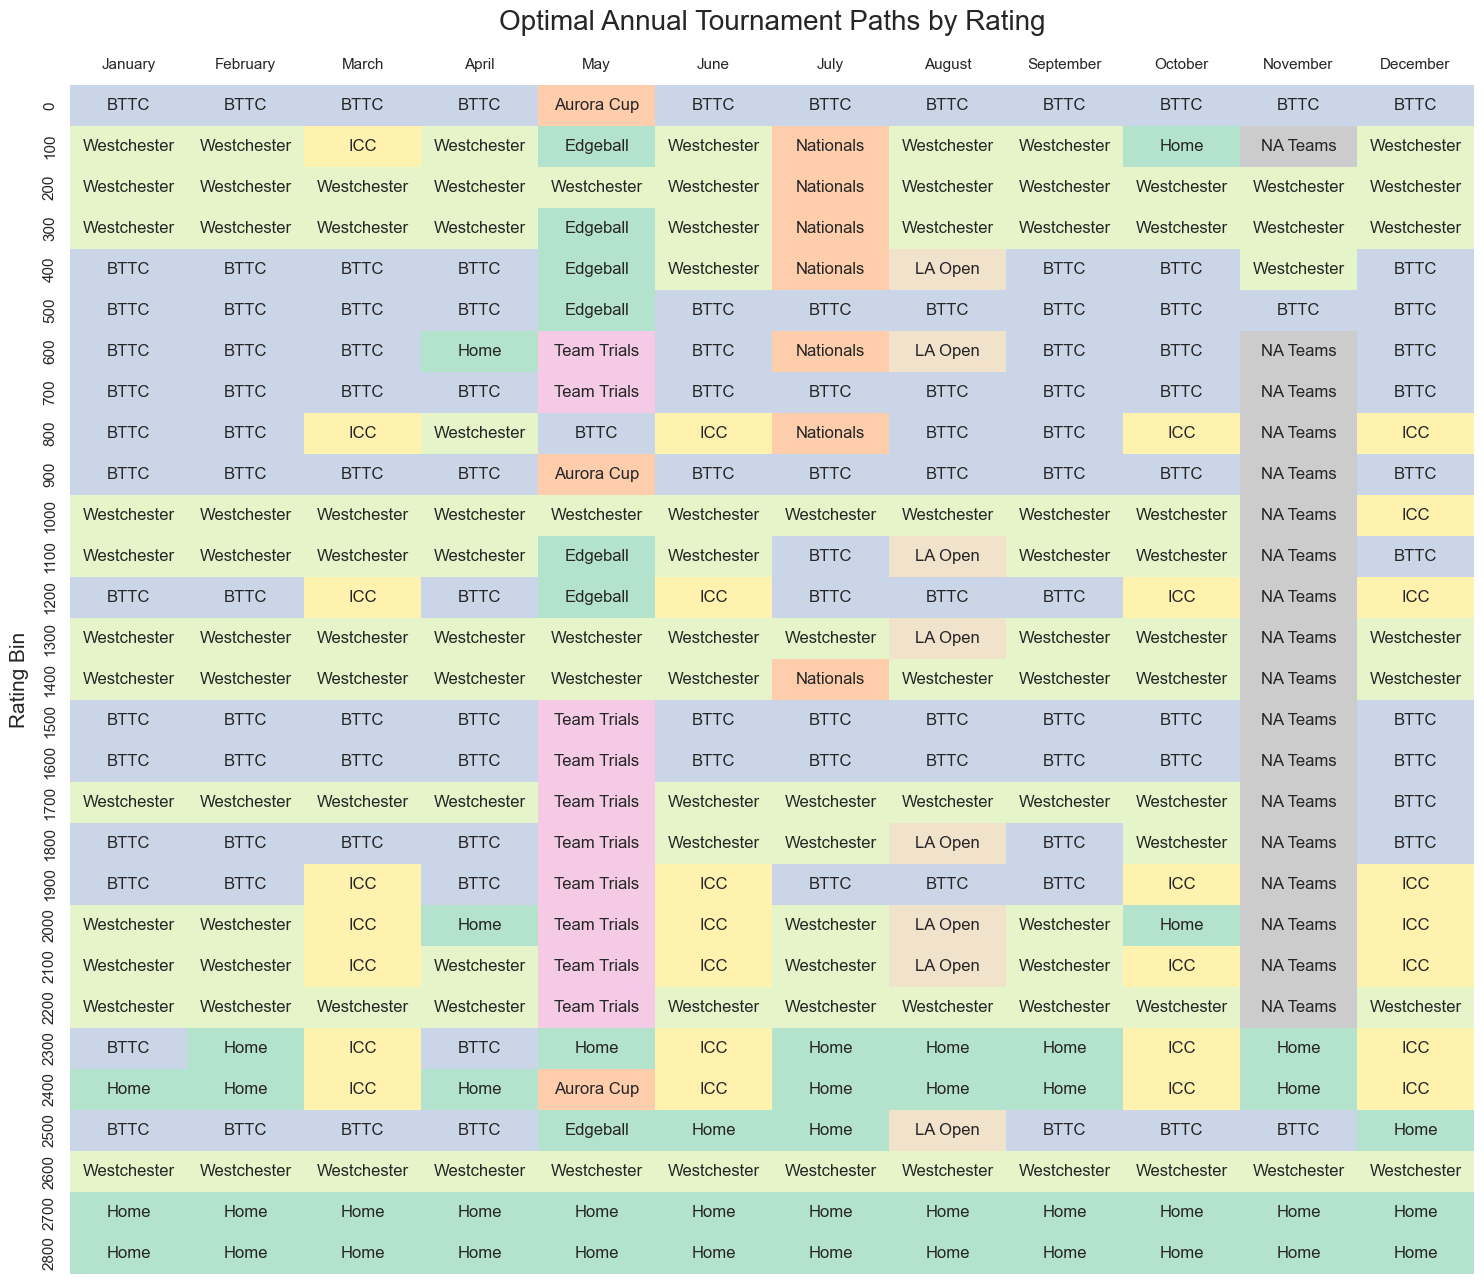

In [97]:
tournament_list = [Tournament(tournaments[i], dates[i], costs.iloc[i], P[i], rewards, expected_rewards[i], mean_expected_rewards[i]) for i in range(len(tournaments))]
value_to_int = {j:i for i,j in enumerate(tournament_list)}
n = len(value_to_int)
cmap = sns.color_palette("Pastel2", n)

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(pd.DataFrame(optimal_path.T).replace(value_to_int), cmap=cmap, annot=optimal_path.T.astype(str), fmt='', cbar=False)
ax.set_title("Optimal Annual Tournament Paths by Rating", fontsize=20, pad=20)
ax.set_ylabel("Rating Bin", fontsize=15, labelpad=10)
ax.set_xticklabels(["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"])
ax.set_yticklabels([100*i for i in range(29)])
ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False, labeltop=True)
plt.tight_layout()
plt.show()

In [62]:
optimal_path.astype(str).dtype

dtype('<U11')

## Pareto Frontier

In [15]:
bin = rating // 100
paths = mdp.find_paths()

cost_paths = []
expected_reward_paths = []
for path in paths:
    reward = np.zeros(p_size)
    reward[bin] = 1
    cost = 0
    for tournament in path:
        reward = reward @ tournament.reward
        cost += tournament.cost
    expected_reward_paths.append(np.dot(reward, np.arange(p_size) - bin))
    cost_paths.append(cost)

expected_reward_paths = np.array(expected_reward_paths)
cost_paths = np.array(cost_paths)

In [16]:
def pareto_frontier(reward_paths, cost_paths):
    sorted_data = pd.DataFrame({'reward': reward_paths, 'cost': cost_paths}).sort_values(by='cost')
    
    previous = sorted_data.iloc[0, 0]
    pareto_index = [sorted_data.index[0]]
    pareto_rewards = [sorted_data.iloc[0, 0]]
    pareto_costs = [sorted_data.iloc[0, 1]]

    i = 0
    n = len(sorted_data)
    for i in range(n):
        if sorted_data.iloc[i, 0] > previous:
            pareto_index.append(sorted_data.index[i])
            pareto_rewards.append(sorted_data.iloc[i, 0])
            pareto_costs.append(sorted_data.iloc[i, 1])
            previous = sorted_data.iloc[i, 0]
    
    return pareto_index, pareto_rewards, pareto_costs

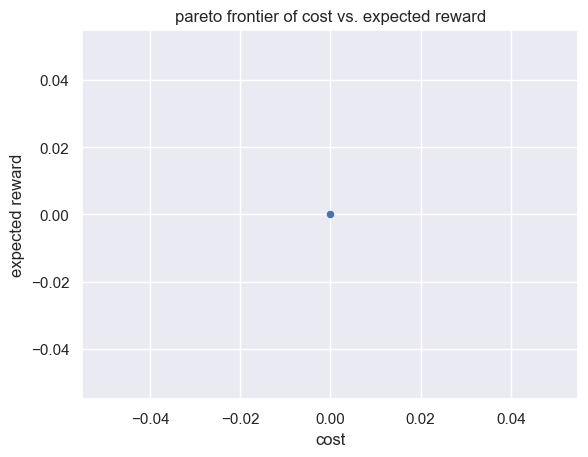

In [17]:
pareto_index, pareto_rewards, pareto_costs = pareto_frontier(expected_reward_paths, cost_paths)
sns.scatterplot(x=pareto_costs, y=pareto_rewards)
plt.title('pareto frontier of cost vs. expected reward')
plt.xlabel('cost')
plt.ylabel('expected reward')
plt.show()

<Axes: >

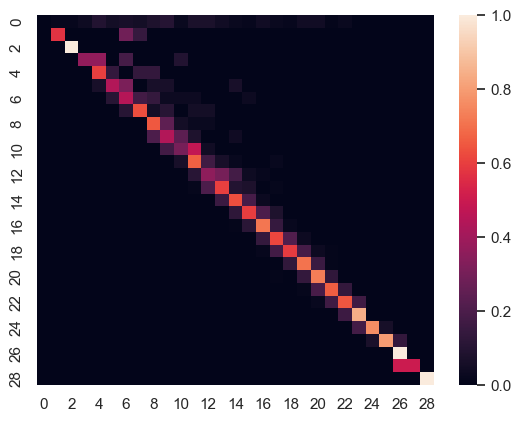

In [85]:
sns.heatmap(rewards[8])